IMports and setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TARGET_COLUMN, MODEL_RESULTS, PROCESSED_DATA

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from src.preprocessing_utils import (
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    evaluate_regression_model,
    plot_actual_vs_predicted,
    plot_training_history,
    save_model
)

pd.set_option("display.max_columns", None)

#### Model Optimization

This notebook improves the previously developed models through hyperparameter tuning and controlled experimentation.  
The optimization focuses on Random Forest and LSTM models, followed by a comparison of performance before and after tuning.

Load datasets

In [2]:
train_file_path = PROCESSED_DATA / "train_feature_engineered_data.csv"
test_file_path = PROCESSED_DATA / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_file_path)
test_df = load_feature_engineered_dataset(test_file_path)

train_df = parse_datetime_index(train_df, datetime_column="date")
test_df = parse_datetime_index(test_df, datetime_column="date")

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 21)
Testing set shape: (3945, 21)


Target and features split

In [3]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

Scaling

In [4]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 20)
Scaled X_test shape: (3945, 20)


## Optimization
#### Optimization Strategy

Two models were selected for optimization:

- Random Forest, because it achieved the best initial performance
- LSTM, because it is the main deep learning model and may improve with better tuning

The optimization experiments focus on improving generalization and reducing prediction error.

           .................

Random Forest - Optimization

In [5]:
optimized_random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

optimized_random_forest_model.fit(
    x_train_scaled,
    y_train_series.to_numpy(),
)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [6]:
# saving the Random Forest model
save_model(
    model=optimized_random_forest_model,
    file_name="optimized_random_forest_model.pkl",
)

In [7]:
optimized_random_forest_predictions = optimized_random_forest_model.predict(x_test_scaled)

optimized_random_forest_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=optimized_random_forest_predictions,
)

optimized_random_forest_metrics

{'MAE': 11.05, 'RMSE': 17.44, 'MAPE': 14.17, 'R2': 0.8}

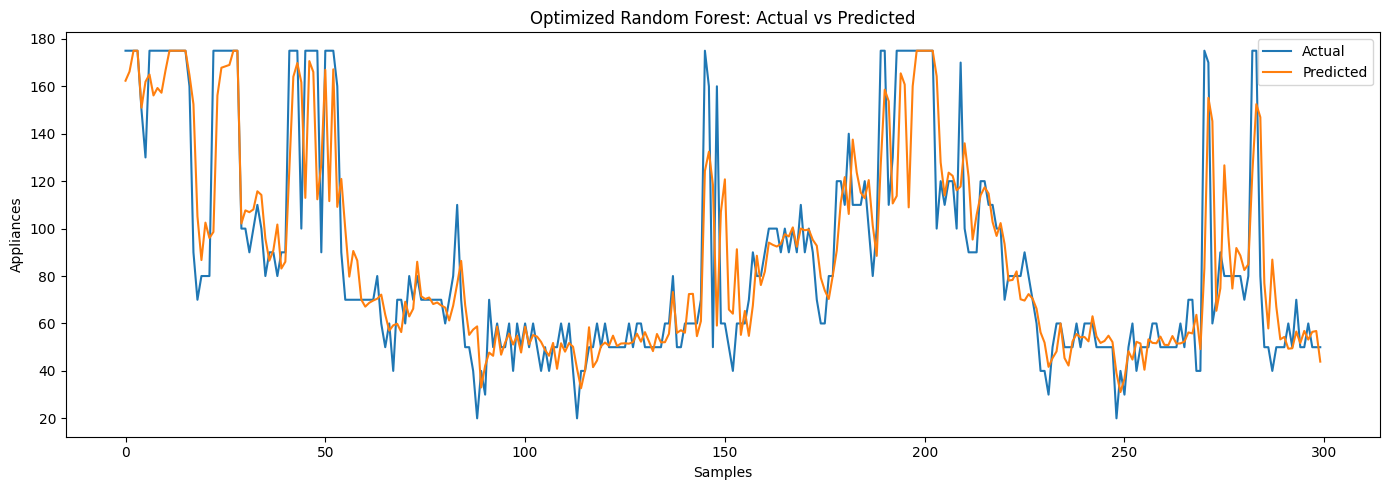

In [8]:
# plotting predictions

plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=optimized_random_forest_predictions[:300],
    title="Optimized Random Forest: Actual vs Predicted",
    file_name="optimized_random_forest_actual_vs_predicted"
)

- The Random Forest model was tuned by increasing the number of trees and constraining tree growth using depth and minimum sample parameters.  
- This helps reduce overfitting while preserving the model’s ability to capture non-linear relationships.

...........

LSTM

In [9]:
optimized_sequence_length = 12

x_train_seq_opt, y_train_seq_opt = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

x_test_seq_opt, y_test_seq_opt = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

print("x_train_seq_opt shape:", x_train_seq_opt.shape)
print("y_train_seq_opt shape:", y_train_seq_opt.shape)
print("x_test_seq_opt shape:", x_test_seq_opt.shape)
print("y_test_seq_opt shape:", y_test_seq_opt.shape)

x_train_seq_opt shape: (15767, 12, 20)
y_train_seq_opt shape: (15767,)
x_test_seq_opt shape: (3933, 12, 20)
y_test_seq_opt shape: (3933,)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_optimized_lstm_model(input_shape):
    model = Sequential()

    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(LSTM(64))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    return model


# Define optimizer
optimizer = Adam(learning_rate=0.0009)

# Create model
lstm_model_opt = create_optimized_lstm_model(
    input_shape=(x_train_seq_opt.shape[1], x_train_seq_opt.shape[2])
)

# Compile
lstm_model_opt.compile(
    optimizer=optimizer,
    loss="mse"
)

lstm_model_opt.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,761 (491.25 KB)

 Trainable params: 125,761 (491.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_opt = lstm_model_opt.fit(
    x_train_seq_opt,
    y_train_seq_opt,
    validation_split=0.1,
    epochs=35,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6275.4844 - val_loss: 3359.2148
Epoch 2/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 3433.3162 - val_loss: 2117.4663
Epoch 3/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2452.4727 - val_loss: 1657.5352
Epoch 4/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2108.7827 - val_loss: 1532.0081
Epoch 5/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1989.3086 - val_loss: 1509.6316
Epoch 6/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1877.9791 - val_loss: 1109.2356
Epoch 7/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1285.4878 - val_loss: 856.5594
Epoch 8/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1023.5248 - val_loss: 718.4465
Epoch 9/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 948.1243 - val_loss: 623.5887
Epoch 10/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 797.0531 - val_loss: 550.5500
Epoch 11/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 724.8189 - val_loss: 514

In [12]:
# saving the LSTM model
save_model(
    model=lstm_model_opt,
    file_name="optimized_lstm_model.pkl",
)

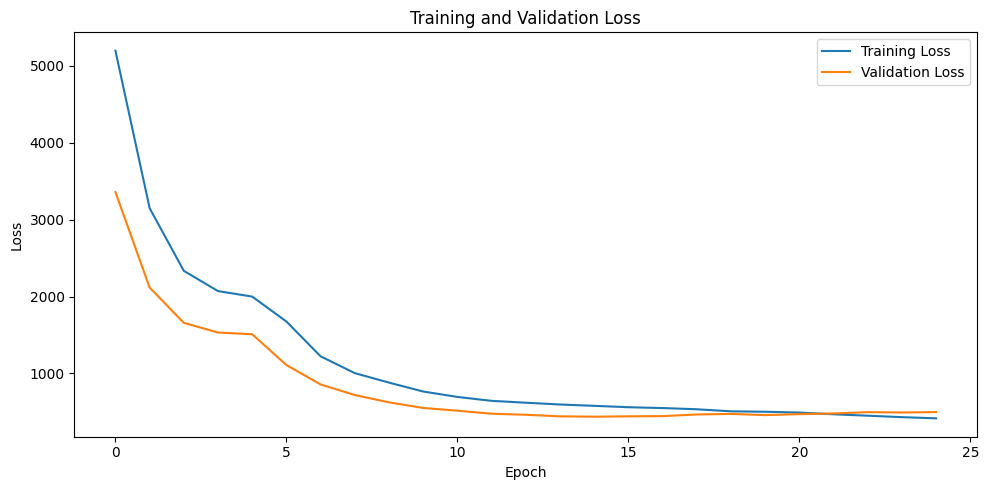

In [13]:
# plotting training

plot_training_history(history_opt)

In [14]:
# Predictions
y_pred_opt = lstm_model_opt.predict(x_test_seq_opt).flatten()

# Evaluate
from src.model_utils import evaluate_regression_model

optimized_lstm_metrics = evaluate_regression_model(
    y_true=y_test_seq_opt,
    y_pred=y_pred_opt
)

optimized_lstm_metrics

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'MAE': 14.13, 'RMSE': 22.29, 'MAPE': 17.22, 'R2': 0.67}

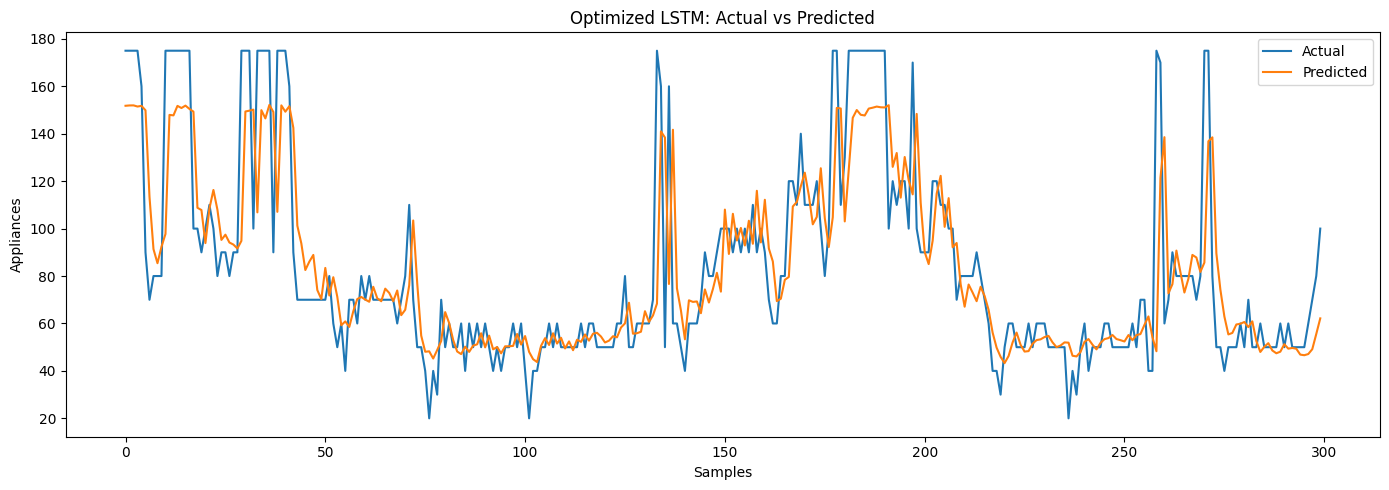

In [15]:
from src.model_utils import plot_actual_vs_predicted

plot_actual_vs_predicted(
    y_true=y_test_seq_opt[:300],
    y_pred=y_pred_opt[:300],
    title="Optimized LSTM: Actual vs Predicted",
    file_name="optimized_lstm_actual_vs_predicted"
)

#### Comparison

In [16]:
# results before optimization

previous_results_df = pd.DataFrame(
    [
        {"model": "Linear Regression", "MAE": 15.570595, "RMSE": 22.553753},
        {"model": "Random Forest", "MAE": 14.802757, "RMSE": 21.402411},
        {"model": "LSTM", "MAE": 16.567993, "RMSE": 25.496047},
    ]
)

previous_results_df

,model,MAE,RMSE
0,Linear Regression,15.570595,22.553753
1,Random Forest,14.802757,21.402411
2,LSTM,16.567993,25.496047


In [17]:
# results after optimization

optimized_results_df = pd.DataFrame(
    [
        {
            "model": "Optimized Random Forest",
            "MAE": optimized_random_forest_metrics["MAE"],
            "RMSE": optimized_random_forest_metrics["RMSE"],
        },
        {
            "model": "Optimized LSTM",
            "MAE": optimized_lstm_metrics["MAE"],
            "RMSE": optimized_lstm_metrics["RMSE"],
        },
    ]
)

optimized_results_df

,model,MAE,RMSE
0,Optimized Random Forest,11.05,17.44
1,Optimized LSTM,14.13,22.29


In [18]:
# results altogether

all_results_df = pd.concat(
    [previous_results_df, optimized_results_df],
    ignore_index=True,
)

all_results_df

,model,MAE,RMSE
0,Linear Regression,15.570595,22.553753
1,Random Forest,14.802757,21.402411
2,LSTM,16.567993,25.496047
3,Optimized Random Forest,11.050000,17.440000
4,Optimized LSTM,14.130000,22.290000


In [19]:
# checks

all_results_df.sort_values(by="RMSE", ascending=True)

,model,MAE,RMSE
3,Optimized Random Forest,11.050000,17.440000
1,Random Forest,14.802757,21.402411
4,Optimized LSTM,14.130000,22.290000
0,Linear Regression,15.570595,22.553753
2,LSTM,16.567993,25.496047


saving optimized model comparison

In [20]:
optimization_results_path = MODEL_RESULTS / "optimization_results.csv"
all_results_df.to_csv(optimization_results_path, index=False)

print(f"Saved optimization results to: {optimization_results_path}")

Saved optimization results to: E:\Vectorium Labs\energy-forecast\outputs\model_results\optimization_results.csv
